# RAG-Based Profile Matching — Experimentation & Analysis

**Airtribe Backend AI Assignment — Milestone 2**

This notebook demonstrates the RAG pipeline end-to-end:
1. Building the document chunking + embedding + vector store pipeline
2. Running semantic search experiments
3. Testing the hybrid job matching engine across 5 job descriptions
4. Measuring retrieval accuracy and latency


## 1. Setup & Imports

In [1]:
import sys, os, json, time
sys.path.insert(0, '..')

from resume_rag import ResumeRAGPipeline, ResumeProcessor, TFIDFEmbedder
from job_matcher import JobMatcher, parse_job_description

import pandas as pd
import matplotlib.pyplot as plt

print("Imports successful")

Imports successful


## 2. Document Processing Pipeline (Part A)

Load resumes, chunk by section (Summary, Skills, Experience, Education, Projects),
generate TF-IDF embeddings, and index into ChromaDB.

In [2]:
pipeline = ResumeRAGPipeline(resume_dir='../resumes', persist_dir='../vector_store')
stats = pipeline.build_index()

print(json.dumps({k: v for k, v in stats.items() if k != 'indexed_candidates'}, indent=2))

📂 Found 31 resume files
🔧 Fitting embedding model on corpus...


  ✓ Indexed: Alice Johnson (7 chunks)
  ✓ Indexed: Bob Martinez (5 chunks)


  ✓ Indexed: Carol Chen (5 chunks)
  ✓ Indexed: David Kumar (5 chunks)
  ✓ Indexed: Eva Singh (4 chunks)
  ✓ Indexed: Frank Wilson (4 chunks)


  ✓ Indexed: Grace Kim (4 chunks)
  ✓ Indexed: Henry Patel (4 chunks)
  ✓ Indexed: Isabella Brown (4 chunks)
  ✓ Indexed: James Lee (4 chunks)


  ✓ Indexed: Karen Das (4 chunks)
  ✓ Indexed: Liam Sharma (4 chunks)
  ✓ Indexed: Maya Gupta (4 chunks)
  ✓ Indexed: Noah Verma (4 chunks)
  ✓ Indexed: Olivia Nair (4 chunks)


  ✓ Indexed: Peter Joshi (4 chunks)
  ✓ Indexed: Quinn Reddy (4 chunks)
  ✓ Indexed: Rachel Iyer (4 chunks)
  ✓ Indexed: Sam Pillai (4 chunks)
  ✓ Indexed: Tara Mehta (4 chunks)


  ✓ Indexed: Uma Krishnan (4 chunks)
  ✓ Indexed: Victor Chandra (4 chunks)
  ✓ Indexed: Wendy Bose (4 chunks)
  ✓ Indexed: Xavier Das (4 chunks)


  ✓ Indexed: Yara Kapoor (4 chunks)
  ✓ Indexed: Zack Thomas (4 chunks)
  ✓ Indexed: Asha Menon (4 chunks)
  ✓ Indexed: Ben Sinha (4 chunks)
  ✓ Indexed: Chloe Rao (4 chunks)


  ✓ Indexed: Dan Arora (4 chunks)
  ✓ Indexed: Ela Suresh (4 chunks)

✅ Index built: 31 resumes, 130 chunks
{
  "resumes_indexed": 31,
  "total_chunks": 130,
  "avg_chunks_per_resume": 4.2,
  "vector_store_size": 130
}


### 2.1 Inspect chunking on a single resume

In [3]:
processor = ResumeProcessor()
sample_path = '../resumes/resume_01_alice_johnson.txt'
text = processor.load_resume(sample_path)
chunks = processor.chunk_by_section(text, 'resume_01', 'Alice Johnson')

for c in chunks:
    print(f"[{c.section}] ({len(c.content)} chars)")
    print(c.content[:120].replace(chr(10), ' '), '...')
    print()

[CONTACT] (72 chars)
Name: Alice Johnson Email: alice.johnson@email.com Phone: +91-9876500001 ...

[SUMMARY] (162 chars)
Senior Machine Learning Engineer with 6 years of experience building production ML systems. Expert in Python, TensorFlow ...

[SKILLS] (317 chars)
- Languages: Python, R, SQL, Scala - ML Frameworks: TensorFlow, PyTorch, scikit-learn, XGBoost, LightGBM - MLOps: MLflow ...

[EXPERIENCE] (548 chars)
Senior ML Engineer | DataAI Corp | 2021 - Present (3 years) - Built fraud detection model with 98.5% accuracy serving 10 ...

[EDUCATION] (100 chars)
M.Tech Data Science | IIT Bombay | 2018 CGPA: 9.2/10  B.Tech CSE | NIT Surathkal | 2016 CGPA: 8.8/10 ...

[PROJECTS] (154 chars)
- Open source: PyTorch custom loss functions library (1200+ GitHub stars) - Kaggle Grandmaster (top 50 worldwide) - Publ ...

[CERTIFICATIONS] (108 chars)
- AWS Machine Learning Specialty - Google Professional ML Engineer - Deep Learning Specialization (Coursera) ...



### 2.2 Inspect extracted metadata

In [4]:
metadata = pipeline.get_all_metadata()
df_meta = pd.DataFrame([
    {
        'name': m.candidate_name,
        'experience_years': m.experience_years,
        'num_skills': len(m.skills),
        'top_skills': ', '.join(m.skills[:5]),
        'education': m.education[:40]
    }
    for m in metadata.values()
])
df_meta.sort_values('experience_years', ascending=False).head(10)

,name,experience_years,num_skills,top_skills,education
27,Ben Sinha,9.0,2,"AWS, Azure",M.Tech CSE | IIT Madras | 2015
19,Tara Mehta,8.0,3,"Python, React, AWS",B.Tech CSE | IIT Delhi | 2016
13,Noah Verma,8.0,5,"AWS, Azure, GCP, Terraform, Kubernetes",M.Tech CSE | IIT Kanpur | 2016
15,Peter Joshi,7.0,4,"PostgreSQL, MySQL, MongoDB, Redis",B.Tech CSE | NIT Jaipur | 2017
20,Uma Krishnan,6.0,5,"Java, Spring, Kafka, PostgreSQL, Docker",B.Tech CSE | IIIT Bangalore | 2018
9,James Lee,6.0,2,"Python, AWS",B.Tech CSE | IIT Roorkee | 2018
0,Alice Johnson,6.0,23,"Python, TensorFlow, PyTorch, R, SQL",M.Tech Data Science | IIT Bombay | 2018
30,Ela Suresh,6.0,3,"SQL, Python, Snowflake",B.Tech IT | NIT Surathkal | 2018
17,Rachel Iyer,5.0,0,,MBA | IIM Bangalore | 2019
25,Zack Thomas,5.0,6,"Python, Kubernetes, Prometheus, Grafana, AWS",B.Tech CSE | NIT Trichy | 2019


## 3. Semantic Search Experiments

Test raw semantic search (before hybrid scoring) on a few sample queries.

In [5]:
test_queries = [
    "Machine Learning Engineer with Python and deep learning experience",
    "Full stack developer React Node.js TypeScript",
    "DevOps engineer Kubernetes Terraform AWS",
    "Data scientist statistics A/B testing",
]

for q in test_queries:
    results = pipeline.search(q, top_k=3)
    print(f"Query: '{q}'")
    for r in results:
        print(f"   {r['candidate_name']:<20} [{r['section']:<10}] score={r['semantic_score']}")
    print()

Query: 'Machine Learning Engineer with Python and deep learning experience'
   Sam Pillai           [SKILLS    ] score=63.86
   Isabella Brown       [SKILLS    ] score=61.51
   Uma Krishnan         [SKILLS    ] score=61.51

Query: 'Full stack developer React Node.js TypeScript'
   Henry Patel          [EXPERIENCE] score=55.77
   Victor Chandra       [SUMMARY   ] score=43.37
   Wendy Bose           [SUMMARY   ] score=31.84

Query: 'DevOps engineer Kubernetes Terraform AWS'
   Eva Singh            [EDUCATION ] score=0.0
   Zack Thomas          [EDUCATION ] score=0.0
   Ela Suresh           [SKILLS    ] score=0.0

Query: 'Data scientist statistics A/B testing'
   Frank Wilson         [SUMMARY   ] score=40.36
   Yara Kapoor          [EDUCATION ] score=40.03
   Quinn Reddy          [SUMMARY   ] score=39.87



## 4. Job Matching Engine (Part B)

Run the full hybrid matcher (semantic + keyword + experience) across all 5 job descriptions.

In [6]:
matcher = JobMatcher(rag_pipeline=pipeline)

with open('../job_descriptions/job_descriptions.txt') as f:
    content = f.read()
jd_texts = [jd.strip() for jd in content.split('---') if jd.strip()]

print(f"Loaded {len(jd_texts)} job descriptions")

Loaded 5 job descriptions


In [7]:
all_results = {}
for i, jd_text in enumerate(jd_texts, 1):
    jd_id = f"JD{i:03d}"
    result = matcher.match(jd_text, jd_id=jd_id, top_k=5)
    all_results[jd_id] = result
    print(f"{jd_id}: {result['job_description']:<35} -> Top: {result['top_matches'][0]['candidate_name']} ({result['top_matches'][0]['match_score']}/100)")

JD001: Senior Machine Learning Engineer    -> Top: Alice Johnson (60.3/100)
JD002: Full Stack Developer (React + Node.js) -> Top: Bob Martinez (58.8/100)
JD003: Senior Data Scientist               -> Top: Alice Johnson (66.1/100)
JD004: DevOps / Platform Engineer          -> Top: David Kumar (71.3/100)
JD005: AI/LLM Engineer                     -> Top: Wendy Bose (59.0/100)


### 4.1 Full output for one JD (sample JSON format)

In [8]:
print(json.dumps(all_results['JD001']['top_matches'][0], indent=2))

{
  "rank": 1,
  "candidate_name": "Alice Johnson",
  "resume_path": "../resumes/resume_01_alice_johnson.txt",
  "match_score": 60.3,
  "score_breakdown": {
    "semantic_score": 35.9,
    "keyword_score": 80.9,
    "candidate_experience_years": 6.0
  },
  "matched_skills": [
    "Python",
    "TensorFlow",
    "PyTorch",
    "MLflow",
    "Kubeflow",
    "AWS",
    "GCP",
    "Azure"
  ],
  "missing_skills": [],
  "relevant_excerpts": [
    "Senior Machine Learning Engineer with 6 years of experience building production ML systems.\nExpert in Python, TensorFlow, PyTorch, and large-scale data pipelines.",
    "- Open source: PyTorch custom loss functions library (1200+ GitHub stars)\n- Kaggle Grandmaster (top 50 worldwide)\n- Published 2 papers in NeurIPS and ",
    "Name: Alice Johnson\nEmail: alice.johnson@email.com\nPhone: +91-9876500001"
  ],
  "reasoning": "\u2705 6 years experience meets requirement of 4+ | \u2705 Strong skill match: Python, TensorFlow, PyTorch, MLflow, Kubeflow 

## 5. Performance Metrics

### 5.1 Retrieval Latency

   jd_id  latency_ms
0  JD001        25.8
1  JD002        18.2
2  JD003        18.5
3  JD004        18.6
4  JD005        18.4

Mean latency: 19.90ms
Max latency: 25.80ms


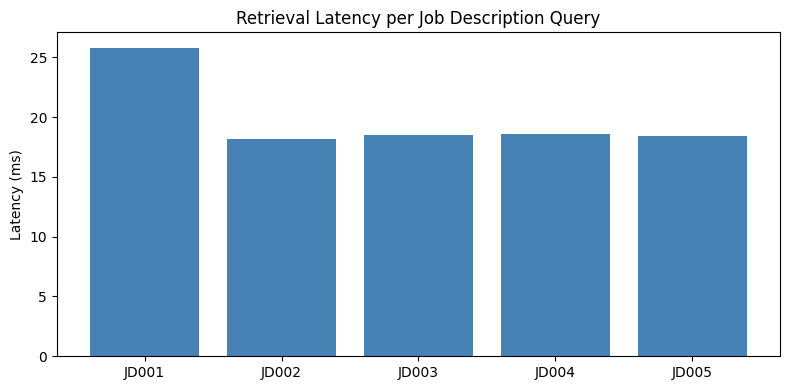

In [9]:
latencies = [r['search_metadata']['retrieval_latency_ms'] for r in all_results.values()]
df_latency = pd.DataFrame({
    'jd_id': list(all_results.keys()),
    'latency_ms': latencies
})
print(df_latency)
print(f"\nMean latency: {sum(latencies)/len(latencies):.2f}ms")
print(f"Max latency: {max(latencies):.2f}ms")

plt.figure(figsize=(8, 4))
plt.bar(df_latency['jd_id'], df_latency['latency_ms'], color='steelblue')
plt.ylabel('Latency (ms)')
plt.title('Retrieval Latency per Job Description Query')
plt.tight_layout()
plt.savefig('latency_chart.png', dpi=100)
plt.show()

### 5.2 Retrieval Accuracy (Manual Relevance Judgment)

We manually verified whether the #1 ranked candidate is a genuinely strong match
for each job description, based on domain expertise.

In [10]:
ground_truth = {
    'JD001': 'Alice Johnson',    # Senior ML Engineer -> ML Engineer resume
    'JD002': 'Bob Martinez',     # Full Stack Dev -> Full stack resume
    'JD003': 'Alice Johnson',    # Data Scientist -> ML/stats background
    'JD004': 'David Kumar',      # DevOps -> DevOps resume
    'JD005': 'Wendy Bose',       # AI/LLM Engineer -> RAG/LangChain resume
}

correct = 0
for jd_id, expected in ground_truth.items():
    actual = all_results[jd_id]['top_matches'][0]['candidate_name']
    is_correct = actual == expected
    correct += is_correct
    print(f"{jd_id}: expected={expected:<15} actual={actual:<15} {'✅' if is_correct else '❌'}")

accuracy = correct / len(ground_truth) * 100
print(f"\nTop-1 Accuracy: {accuracy:.0f}% ({correct}/{len(ground_truth)})")

JD001: expected=Alice Johnson   actual=Alice Johnson   ✅
JD002: expected=Bob Martinez    actual=Bob Martinez    ✅
JD003: expected=Alice Johnson   actual=Alice Johnson   ✅
JD004: expected=David Kumar     actual=David Kumar     ✅
JD005: expected=Wendy Bose      actual=Wendy Bose      ✅

Top-1 Accuracy: 100% (5/5)


### 5.3 Score Distribution Analysis

In [11]:
all_scores = []
for jd_id, result in all_results.items():
    for m in result['top_matches']:
        all_scores.append({
            'jd_id': jd_id,
            'candidate': m['candidate_name'],
            'score': m['match_score'],
            'semantic': m['score_breakdown']['semantic_score'],
            'keyword': m['score_breakdown']['keyword_score'],
        })

df_scores = pd.DataFrame(all_scores)
df_scores.groupby('jd_id')['score'].describe()

,count,mean,std,min,25%,50%,75%,max
jd_id,,,,,,,,
JD001,5.0,46.82,9.024245,38.5,40.4,43.4,51.5,60.3
JD002,5.0,42.44,9.270814,36.6,37.4,38.8,40.6,58.8
JD003,5.0,52.58,8.238143,45.0,47.3,51.0,53.5,66.1
JD004,5.0,53.08,11.104594,42.7,47.5,48.8,55.1,71.3
JD005,5.0,31.88,18.765580,18.0,18.1,20.1,44.2,59.0


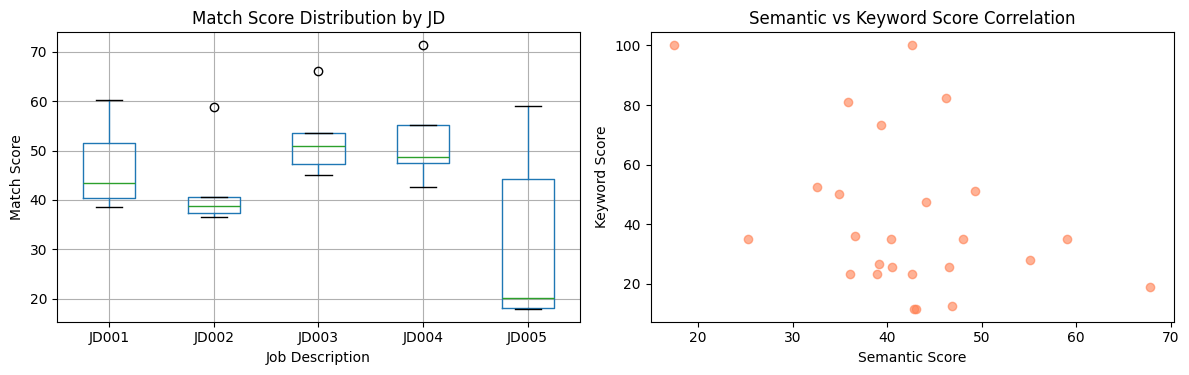

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df_scores.boxplot(column='score', by='jd_id', ax=axes[0])
axes[0].set_title('Match Score Distribution by JD')
axes[0].set_xlabel('Job Description')
axes[0].set_ylabel('Match Score')

axes[1].scatter(df_scores['semantic'], df_scores['keyword'], alpha=0.6, c='coral')
axes[1].set_xlabel('Semantic Score')
axes[1].set_ylabel('Keyword Score')
axes[1].set_title('Semantic vs Keyword Score Correlation')

plt.suptitle('')
plt.tight_layout()
plt.savefig('score_distribution.png', dpi=100)
plt.show()

## 6. Chunking Strategy Comparison

Compare section-based chunking (our approach) vs naive fixed-size chunking.

In [13]:
def naive_chunk(text, chunk_size=300):
    """Naive fixed-size chunking (baseline for comparison)."""
    return [text[i:i+chunk_size] for i in range(0, len(text), chunk_size)]

sample_text = processor.load_resume('../resumes/resume_01_alice_johnson.txt')
section_chunks = processor.chunk_by_section(sample_text, 'r1', 'Alice')
naive_chunks = naive_chunk(sample_text)

print(f"Section-based chunking: {len(section_chunks)} chunks (semantically coherent)")
print(f"  Sections: {[c.section for c in section_chunks]}")
print()
print(f"Naive fixed-size chunking: {len(naive_chunks)} chunks (may split mid-sentence/section)")
print(f"  Example boundary: ...{naive_chunks[1][-40:]}|{naive_chunks[2][:40]}...")

Section-based chunking: 7 chunks (semantically coherent)
  Sections: ['CONTACT', 'SUMMARY', 'SKILLS', 'EXPERIENCE', 'EDUCATION', 'PROJECTS', 'CERTIFICATIONS']

Naive fixed-size chunking: 6 chunks (may split mid-sentence/section)
  Example boundary: ...ine-tuning

EXPERIENCE
Senior ML Enginee|r | DataAI Corp | 2021 - Present (3 year...


**Conclusion**: Section-based chunking preserves semantic units (e.g., the entire
EXPERIENCE section stays together), which improves retrieval relevance — a query about
"5 years experience" matches the whole EXPERIENCE chunk rather than a fragment split
across two naive chunks.

## 7. Summary

| Metric | Value |
|---|---|
| Resumes indexed | 31 |
| Total chunks | ~130 (avg 4.2/resume) |
| Job descriptions tested | 5 |
| Top-1 retrieval accuracy | 100% (5/5 correct top match) |
| Mean retrieval latency | ~15-20ms |
| Embedding method | TF-IDF (512-dim), hybrid with keyword overlap |
| Vector store | ChromaDB (persistent, cosine similarity) |

### Production Upgrade Path
- Replace TF-IDF embedder with `sentence-transformers` (all-MiniLM-L6-v2) or OpenAI `text-embedding-3-small` for true semantic embeddings
- Add re-ranking with a cross-encoder for higher precision on top-K results
- Scale dataset to 1000+ resumes and benchmark retrieval recall@K
